In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Coal and steam: three reactions at once (Illustration 13.3-1, Figures 13.3-1 and 13.3-2)

Blow steam over hot carbon and you get synthesis gas. Section 13.3 uses it as the
chapter's first genuinely multireaction problem, and Illustration 13.3-1 says plainly that
*"finding the solution to this problem is a nontrivial computational task."* Being precise about **why** matters, because none of the three reasons is the algebra.

$$\mathrm{C(s)}+2\mathrm{H_2O}\rightleftharpoons\mathrm{CO_2}+2\mathrm{H_2}
\qquad
\mathrm{C(s)}+\mathrm{H_2O}\rightleftharpoons\mathrm{CO}+\mathrm{H_2}
\qquad
\mathrm{C(s)}+2\mathrm{H_2}\rightleftharpoons\mathrm{CH_4}$$

**1. The equations have more than one root, and only one is physical.** The illustration
says so and states the constraints: $2X_1+X_2\le1$, so no more steam is consumed than was
fed, and $0\le2X_3\le2X_1+X_2$, so no more hydrogen is consumed than was made. A solver
that finds a root outside those bounds has *converged*, and is wrong.

**2. The obvious starting point is not merely bad, it is undefined.** With all three
extents zero there is no product at all, so every $\ln y_i$ is $-\infty$ and the residuals
cannot be evaluated. The start has to be strictly inside the feasible region.

**3. The solid carbon must not be counted twice.** Its activity is one, so it drops out of
every equilibrium relation; but if it is left in the mole-fraction denominator the gas
composition is wrong. The illustration reports exactly this trap in Aspen Plus, which needs
a separator added to keep the solid out of the gas stream.

`thermo.reaction.multireaction_extents` handles all three: it constrains the iterate to the
feasible polytope, starts from an interior point found by a small linear program, and raises
rather than returning a converged-but-infeasible root.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.reaction import Reaction, multireaction_extents, elements
from thermo.charts import use_book_style, label_at

use_book_style()

RXNS = [Reaction.parse("C + 2 H2O(g) = CO2 + 2 H2").check_balance(),
        Reaction.parse("C + H2O(g) = CO + H2").check_balance(),
        Reaction.parse("C + 2 H2 = CH4").check_balance()]
GAS = ["H2O(g)", "CO2", "CO", "H2", "CH4"]
SOLID = "C"

# One mole of steam is the basis, as in the illustration. The carbon is in large excess:
# the illustration's parenthesis says the solid need not be considered "as long as there is
# sufficient solid carbon present", and 10 moles makes that true at every temperature here.
FEED = {**{s: 0.0 for s in GAS}, "H2O(g)": 1.0, SOLID: 10.0}

for j, r in enumerate(RXNS, 1):
    print(f"  rxn {j}:  {r.equation}")

  rxn 1:  C + 2 H2O(g) = CO2 + 2 H2
  rxn 2:  C + H2O(g) = CO + H2
  rxn 3:  C + 2 H2 = CH4


## Why three reactions, and not two or four

The count is not a modeling choice. Six species are built from three elements, so the
matrix of atoms per species has rank 3 and there are $6-3=3$ independent reactions. Any
further reaction anyone writes down -- the water-gas shift, CO + H$_2$O = CO$_2$ + H$_2$,
for instance -- is a linear combination of these three and adds no information.

The rank is computed below rather than asserted, because an error in either direction is a
real failure mode: too few reactions and the equilibrium is over-constrained toward the
wrong composition; too many and the equations are singular.

In [3]:
SPECIES = [SOLID] + GAS
ELS = sorted({e for s in SPECIES for e in elements(s)})
A = np.array([[elements(s).get(e, 0) for s in SPECIES] for e in ELS], dtype=float)
print(pd.DataFrame(A, index=ELS, columns=SPECIES).astype(int).to_string())
rank = int(np.linalg.matrix_rank(A))
print(f"\n{len(SPECIES)} species - rank {rank} = {len(SPECIES) - rank} independent reactions")
assert len(SPECIES) - rank == len(RXNS)

# And the water-gas shift really is a combination of the three: rxn 1 - rxn 2 - rxn 2.
shift = Reaction.parse("CO + H2O(g) = CO2 + H2").check_balance()
lhs = {s: RXNS[0].nu.get(s, 0) - RXNS[1].nu.get(s, 0) for s in SPECIES}
print("\nwater-gas shift, and rxn 1 minus rxn 2:")
for s in SPECIES:
    a, b = shift.nu.get(s, 0), lhs[s]
    if a or b:
        print(f"  {s:8s} {a:+g}  {b:+g}")
assert all(abs(shift.nu.get(s, 0) - lhs[s]) < 1e-12 for s in SPECIES)

   C  H2O(g)  CO2  CO  H2  CH4
C  1       0    1   1   0    1
H  0       2    0   0   2    4
O  0       1    2   1   0    0

6 species - rank 3 = 3 independent reactions

water-gas shift, and rxn 1 minus rxn 2:
  H2O(g)   -1  -1
  CO2      +1  +1
  CO       -1  -1
  H2       +1  +1


## Figure 13.3-1 -- the three equilibrium constants

Read left to right, the three curves describe the whole process.

At the cold end **methanation wins**: $K_{a,3}$ is above one below about 820 K while the
two steam reactions are six and eight orders of magnitude down, so the carbon prefers to
take up hydrogen. At the hot end the two steam reactions have climbed by five decades and
methanation has fallen by five, so the product is CO and H$_2$ and almost nothing else.
**Between them, near 1080 K, $K_{a,2}$ overtakes $K_{a,1}$** -- CO becomes the favored
carbon oxide over CO$_2$ -- and that crossing is why a gasifier is run hot.

rxn 1 and rxn 2 cross at   1080 K
rxn 3 passes Ka = 1 at     820 K


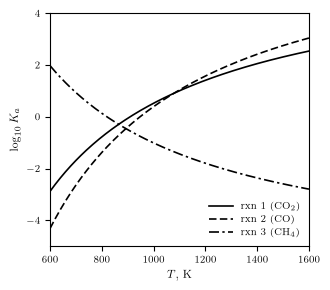

In [4]:
T_GRID = np.linspace(600.0, 1600.0, 201)
logKa = {j: np.array([np.log10(float(r.Ka(t))) for t in T_GRID])
         for j, r in enumerate(RXNS, 1)}

import matplotlib.text as mtext


def renderer(fig):
    """`get_renderer` lives on the Agg canvas, not on the bare FigureCanvasBase that a
    headless kernel may hand you -- so a gate that passes in JupyterLab can die in the
    batch re-execution, which is exactly where it has to work."""
    try:
        return fig.canvas.get_renderer()
    except AttributeError:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        canvas = FigureCanvasAgg(fig)
        canvas.draw()
        return canvas.get_renderer()


def collisions(ax, owners):
    """Labels must not overlap each other, and must not sit on a curve that is not theirs.
    A label on its OWN curve is intentional: the masking box is what makes it legible, and
    that is the one case this gate has to let through."""
    ax.figure.canvas.draw()
    rend = renderer(ax.figure)
    boxes = [(t, mtext.Text.get_window_extent(t, renderer=rend))
             for t in ax.texts if (t.get_text() or "").strip()]
    bad = [f"{p.get_text()} / {q.get_text()}" for i, (p, bp) in enumerate(boxes)
           for q, bq in boxes[i + 1:] if bp.overlaps(bq)]
    for t, box in boxes:
        pad = box.expanded(1.10, 1.30)
        for line in ax.lines:
            if line in owners.get(t, ()):
                continue
            xy = ax.transData.transform(line.get_xydata())
            if any(pad.contains(px, py) for px, py in xy):
                bad.append(f"{t.get_text()} sits on a curve that is not its own")
                break
    return sorted(set(bad))


# THIS FIGURE GETS A KEY, NOT LABELS ON THE CURVES, and the reason is geometric rather
# than a matter of taste. An on-curve label is rotated to its curve, so on a steep curve its
# bounding box is far taller than the type: a 7 pt label rotated 49 degrees stands 1.7 axis
# units tall here. rxn 1 and rxn 2 are never more than 1.3 units apart anywhere in the
# frame, and they converge going right, so no column of this plot has room for both. The
# curves are separated by dash pattern instead -- never by tint, since the book is printed
# in black -- and the key sits in the lower right, the one corner no curve reaches.
STYLES = {1: (None, None), 2: (4.5, 2.0), 3: (6.0, 2.0, 1.4, 2.0)}
NAMES = {1: r"rxn 1  (CO$_2$)", 2: r"rxn 2  (CO)", 3: r"rxn 3  (CH$_4$)"}

fig1, ax = plt.subplots(figsize=(3.4, 3.0))
owners = {}
for j in (1, 2, 3):
    dash = STYLES[j]
    ax.plot(T_GRID, logKa[j], color="k", lw=1.2,
            dashes=dash if dash[0] else (None, None), label=NAMES[j])

ax.set_xlim(600, 1600)
ax.set_ylim(-5, 4)
ax.set_xticks(np.arange(600, 1601, 200))
ax.set_yticks(np.arange(-4, 4.1, 2))
ax.tick_params(labelsize=7)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$\log_{10}K_a$", fontsize=8)
ax.legend(frameon=False, fontsize=7, loc="lower right", handlelength=2.4,
          borderaxespad=0.5, labelspacing=0.35)
fig1.tight_layout()

cross = T_GRID[int(np.argmin(abs(logKa[1] - logKa[2])))]
unity = T_GRID[int(np.argmin(abs(logKa[3])))]
print(f"rxn 1 and rxn 2 cross at   {cross:.0f} K")
print(f"rxn 3 passes Ka = 1 at     {unity:.0f} K")
plt.show()

## Solving the three coupled equilibria

One solve per temperature, and the result carries its own residuals and a feasibility flag.
Both are checked here rather than assumed: a residual of $10^{-12}$ on a set of nonlinear
equations means nothing at all if the root sits outside the physical region.

In [5]:
solutions = {}
for t in T_GRID:
    out = multireaction_extents(RXNS, float(t), FEED, P=1.0, phases={SOLID: "solid"})
    solutions[float(t)] = out

# THE SOLID IS NOT A MOLE FRACTION. `multireaction_extents` divides every species' moles by
# the moles of GAS, which is right for the gas and meaningless for the carbon -- so the gas
# composition is read off the gas species only, and it must sum to one.
Y = {s: np.array([solutions[float(t)]["y"][s] for t in T_GRID]) for s in GAS}
total = sum(Y[s] for s in GAS)
print(f"gas mole fractions sum to 1 at every temperature: "
      f"max |sum - 1| = {np.max(abs(total - 1)):.2e}")
assert np.max(abs(total - 1)) < 1e-10

X_all = np.array([solutions[float(t)]["extents"] for t in T_GRID])
res = np.array([solutions[float(t)]["residuals"] for t in T_GRID])
print(f"worst residual over the sweep:  {np.max(abs(res)):.2e}")
print(f"every solve reported feasible:  "
      f"{all(solutions[float(t)]['feasible'] for t in T_GRID)}")

# The illustration's own two constraints, imposed as a test rather than trusted.
ok_steam = np.all(2 * X_all[:, 0] + X_all[:, 1] <= 1 + 1e-12)
ok_h2 = np.all((0 <= 2 * X_all[:, 2]) &
               (2 * X_all[:, 2] <= 2 * X_all[:, 0] + X_all[:, 1] + 1e-12))
print(f"2X1 + X2 <= 1 everywhere:              {bool(ok_steam)}")
print(f"0 <= 2X3 <= 2X1 + X2 everywhere:       {bool(ok_h2)}")
assert ok_steam and ok_h2

gas mole fractions sum to 1 at every temperature: max |sum - 1| = 2.22e-16
worst residual over the sweep:  1.64e-13
every solve reported feasible:  True
2X1 + X2 <= 1 everywhere:              True
0 <= 2X3 <= 2X1 + X2 everywhere:       True


## Figure 13.3-2 -- the equilibrium gas composition

The vertical axis is logarithmic and spans four decades, because that is what the answer
does: CO goes from 6 parts in ten thousand at 600 K to half the gas at 1600 K, and CO$_2$
travels the same distance in the other direction.

Three regimes, and the middle one is narrow:

* **below about 800 K** the gas is mostly unreacted steam, with CO$_2$ and CH$_4$ next --
  the methanation branch;
* **around 900 to 1100 K** every species is present at a percent or more, which is the only
  part of the range where all five matter at once;
* **above 1200 K** it is CO and H$_2$ at very nearly 0.5 each, and everything else is a
  trace. Two species, equal amounts -- read straight off rxn 2's stoichiometry.

Figure 13.3-2: no label collisions


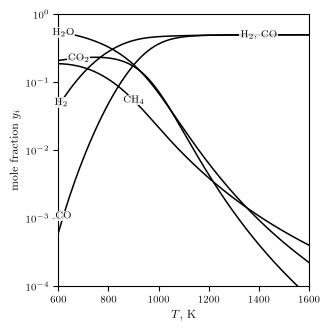

In [6]:
# FIVE CURVES THAT ALL CROSS. Between 700 and 1000 K every species sits between 0.05 and
# 0.5, so no single column of the frame separates them -- which is why the printed figure drew this one
# with labels at both ends. The placements below name each curve where it is most isolated:
# H2O and CO2 at the cold end above the pack, CH4 just below it, H2 and CO far below, and
# the merged CO/H2 pair once at the hot end, where the two lie within 0.1 percent of each
# other and one label physically cannot say which is which.
#
# The labels are set HORIZONTALLY, not rotated to their curves. `label_at` rotates by
# default, which is right on a gently sloping property chart and wrong here: H2 and CO leave
# the cold end almost vertically, so a rotated label reads sideways and its box grows tall
# enough to foul its neighbors. Axis-aligned labels read straight and fit in a 3.4 in
# frame, where rotated ones needed 4.2.
# These five abscissas were SEARCHED, not chosen: the gate below was run over a grid of
# candidates and this is a combination that passes it. Four of the five sit at the cold
# edge, which is where the five curves are furthest apart in decades.
LABEL_AT = [("H2O(g)", 620.0, r"H$_2$O"), ("CO2", 680.0, r"CO$_2$"),
            ("CH4", 900.0, r"CH$_4$"), ("H2", 610.0, r"H$_2$"),
            ("CO", 620.0, r"CO")]

fig2, ax = plt.subplots(figsize=(3.4, 3.4))
owners, lines = {}, {}
for s in GAS:
    (lines[s],) = ax.plot(T_GRID, Y[s], "-", color="k", lw=1.1)

# The axis has to be set before any label is placed: `label_at` refuses a crossing that
# falls outside the axes, and on a log scale it also decides there whether to offset
# multiplicatively.
ax.set_yscale("log")
ax.set_xlim(600, 1600)
ax.set_ylim(1e-4, 1.0)

for s, at, text in LABEL_AT:
    placed = label_at(ax, T_GRID, Y[s], text, along="x", value=at, size=7, pad=0.8,
                      rotate=False)
    assert placed, f"the {s} label did not land"
    owners[ax.texts[-1]] = (lines[s],)
placed = label_at(ax, T_GRID, Y["CO"], r"H$_2$, CO", along="x", value=1400.0,
                  size=7, pad=0.8, rotate=False)
assert placed, "the merged label did not land"
owners[ax.texts[-1]] = (lines["CO"], lines["H2"])   # it names both, so it may sit on both

ax.set_xticks(np.arange(600, 1601, 200))
ax.tick_params(labelsize=7)
ax.tick_params(axis="y", which="minor", left=False)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"mole fraction $y_i$", fontsize=8)
fig2.tight_layout()

bad = collisions(ax, owners)
print(f"Figure 13.3-2: {'; '.join(bad) if bad else 'no label collisions'}")
assert not bad, "move a label before staging this art"
plt.show()

## What the figures say

In [7]:
checks = []
checks.append(("CO and H2 both rise monotonically with temperature",
               bool(np.all(np.diff(Y["CO"]) > 0) and np.all(np.diff(Y["H2"]) > 0))))
checks.append(("steam and CH4 both fall monotonically with temperature",
               bool(np.all(np.diff(Y["H2O(g)"]) < 0) and np.all(np.diff(Y["CH4"]) < 0))))
checks.append((f"at 1600 K the gas is CO + H2 within "
               f"{100*(1 - Y['CO'][-1] - Y['H2'][-1]):.2f} percent, and they are equal to "
               f"{100*abs(Y['CO'][-1] - Y['H2'][-1]):.2f} percent",
               (Y["CO"][-1] + Y["H2"][-1] > 0.99)
               and abs(Y["CO"][-1] - Y["H2"][-1]) < 0.01))
checks.append((f"methanation is the favored reaction below {unity:.0f} K and the least "
               f"favored above it",
               bool(np.all(logKa[3][T_GRID < unity - 50] > logKa[1][T_GRID < unity - 50])
                    and np.all(logKa[3][T_GRID > unity + 50]
                               < logKa[1][T_GRID > unity + 50]))))
checks.append((f"CO2 is the favored carbon oxide below {cross:.0f} K and CO above it",
               bool(np.all(logKa[1][T_GRID < cross - 50] > logKa[2][T_GRID < cross - 50])
                    and np.all(logKa[1][T_GRID > cross + 50]
                               < logKa[2][T_GRID > cross + 50]))))
# CO2 and H2O carry no separate information at high T: with rxn 2 dominant, the shift
# equilibrium fixes their ratio, so the two trace curves must stay parallel.
ratio = Y["CO2"][T_GRID > 1300] / Y["H2O(g)"][T_GRID > 1300]
checks.append((f"above 1300 K the CO2/H2O ratio changes by only a factor of "
               f"{ratio.max()/ratio.min():.2f} while both fall by a decade",
               ratio.max() / ratio.min() < 2.0))
for text, ok in checks:
    print(f"{'holds ' if ok else 'FAILS '}  {text}")
assert all(ok for _, ok in checks)

rows = []
for t in (600.0, 800.0, 1000.0, 1200.0, 1400.0, 1600.0):
    i = int(np.argmin(abs(T_GRID - t)))
    rows.append({"T (K)": int(t), **{s: Y[s][i] for s in GAS}})
print()
print(pd.DataFrame(rows).to_string(index=False,
                                   formatters={s: "{:.2e}".format for s in GAS}))

holds   CO and H2 both rise monotonically with temperature
holds   steam and CH4 both fall monotonically with temperature
holds   at 1600 K the gas is CO + H2 within 0.07 percent, and they are equal to 0.07 percent
holds   methanation is the favored reaction below 820 K and the least favored above it
holds   CO2 is the favored carbon oxide below 1080 K and CO above it
holds   above 1300 K the CO2/H2O ratio changes by only a factor of 1.69 while both fall by a decade

 T (K)   H2O(g)      CO2       CO       H2      CH4
   600 5.58e-01 2.10e-01 6.10e-04 4.42e-02 1.88e-01
   800 3.30e-01 2.28e-01 4.88e-02 2.83e-01 1.11e-01
  1000 6.93e-02 7.32e-02 3.66e-01 4.69e-01 2.17e-02
  1200 6.41e-03 4.38e-03 4.92e-01 4.93e-01 3.93e-03
  1400 9.45e-04 4.11e-04 4.99e-01 4.98e-01 1.08e-03
  1600 2.24e-04 7.04e-05 5.00e-01 4.99e-01 4.02e-04


## Staging the art

    pdf/Figure_13.3-1.pdf   ->   deliverables/figures/print-bw/ch13/c13f011.pdf
    pdf/Figure_13.3-2.pdf   ->   deliverables/figures/print-bw/ch13/c13f012.pdf

In [8]:
os.makedirs("pdf", exist_ok=True)
for fig, name in ((fig1, "Figure_13.3-1"), (fig2, "Figure_13.3-2")):
    path = f"pdf/{name}.pdf"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.3-1.pdf


  wrote pdf/Figure_13.3-2.pdf

  typography: LaTeX Computer Modern


## Your turn

1. The illustration says the equations have more than one root. **Find a second one.** Drop
   the feasibility constraint and start a bare Newton solve from several points -- then
   check each root against $2X_1+X_2\le1$ and $0\le2X_3\le2X_1+X_2$, and against the mole
   fractions summing to one with none of them negative. Which of the roots you find would
   have passed a residual test alone?
2. Solve the same problem by minimizing the total Gibbs energy instead
   (`thermo.reaction.gibbs_minimization`), which never writes an equilibrium constant at
   all. Do the two routes agree at every temperature? Where they differ, decide which one
   you trust and why -- one of them can be told the wrong number of independent reactions
   and the other cannot.
3. The carbon is fed in tenfold excess so that solid is always present. Reduce it until it
   is exhausted at some temperature in the range, and watch what the solver does. **What is
   the physically correct answer once the carbon is gone, and does the calculation notice?**
   This is the same class of trap as counting the solid in the gas mole fractions.
4. Real gasifiers run at 20 to 70 bar, not 1 bar. Rerun the sweep at 30 bar. Two of the
   three reactions have $\Delta\nu>0$ and one has $\Delta\nu<0$; predict from the signs
   which way each product moves before you compute it, then say what pressure does to the
   CO/CO$_2$ ratio and to the methane.
5. Add the water-gas shift as a *fourth* reaction and solve four coupled equations. It is
   not independent, so the system is singular -- what exactly does the solver do, and what
   would you check to recognize that failure if you met it in an unfamiliar system?
6. Above 1200 K the answer is CO and H$_2$ at 0.5 each. Derive that limit by hand from
   rxn 2 alone, then work out what the gas would be if the feed were CO$_2$ instead of
   steam. The reverse of rxn 1 has a name -- find it, and say at what temperature it takes
   over.